In [1]:
#import libraries
import pandas as pd
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)


c:\Users\Charlie\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(0.0, 250000.0)

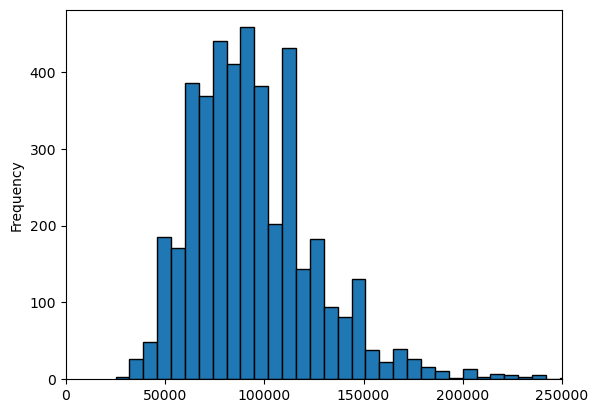

In [15]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US['salary_year_avg'].plot(kind='hist', bins = 50, edgecolor='black')
plt.xlim(0,250000)

C:\Users\Charlie\AppData\Local\Temp\ipykernel_12412\3324812738.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels = job_titles, vert = False)


{'whiskers': [<matplotlib.lines.Line2D at 0x166864608c0>,
 'caps': [<matplotlib.lines.Line2D at 0x16686463590>,
 'boxes': [<matplotlib.lines.Line2D at 0x16686460aa0>,
 'medians': [<matplotlib.lines.Line2D at 0x16686462480>,
 'fliers': [<matplotlib.lines.Line2D at 0x16686461b50>,
 'means': []}

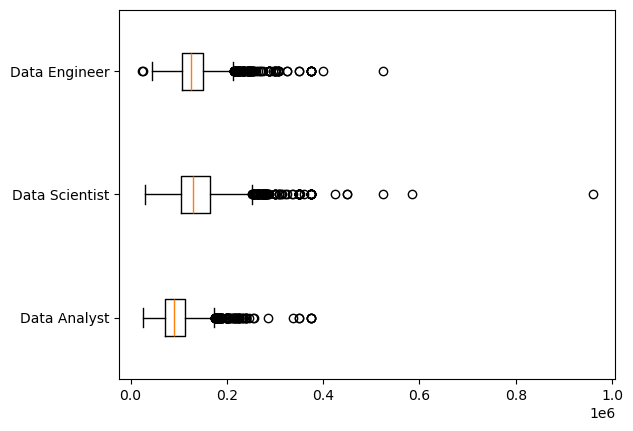

In [34]:
df_DA_US = df_DA_US.dropna(subset = ['salary_year_avg'])

job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
df_US = df[(df['job_title_short'].isin(job_titles))  & (df['job_country'] == 'United States')].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]


plt.boxplot(job_list, labels = job_titles, vert = False)